In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Set a global random seed for reproducibility across all problems
np.random.seed(42)

PROBLEM 1 — Portfolio Construction & Daily Returns

--- PART (a): Prices DataFrame and Daily % Returns ---

Prices DataFrame (₹):
       RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day 1      2800  1450      1600         520
Day 2      2850  1470      1580         535
Day 3      2830  1460      1610         528
Day 4      2900  1490      1625         540
Day 5      2880  1510      1615         555
Day 6      2950  1500      1640         548

Daily Percentage Returns (%) [Day 2 onwards]:
       RELIANCE    INFY  HDFCBANK  TATAMOTORS
Day 1       NaN     NaN       NaN         NaN
Day 2    1.7857  1.3793   -1.2500      2.8846
Day 3   -0.7018 -0.6803    1.8987     -1.3084
Day 4    2.4735  2.0548    0.9317      2.2727
Day 5   -0.6897  1.3423   -0.6154      2.7778
Day 6    2.4306 -0.6623    1.5480     -1.2613

--- PART (b): Units Purchased and Daily Portfolio Value ---

Capital allocated per asset (₹): [250000. 250000. 250000. 250000.]

Units Purchased on Day 1:
RELIANCE       89.2857
INFY          

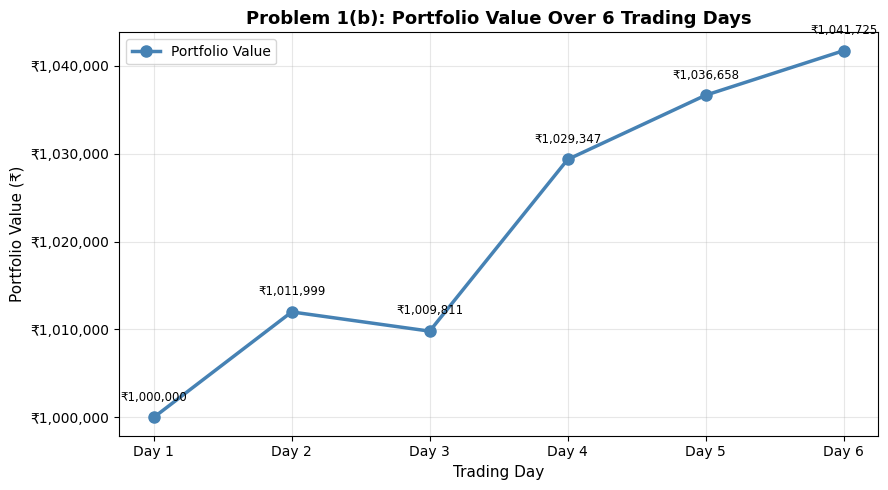

Plot saved: p1b_portfolio_value.png

--- PART (c): Annualised Portfolio Volatility ---

Daily Portfolio Returns:
Day 2    0.011999
Day 3   -0.002162
Day 4    0.019346
Day 5    0.007103
Day 6    0.004888
dtype: float64

Daily Volatility (σ_daily): 0.008034 (0.8034%)
Annualised Volatility (σ_annual = σ_daily × √252): 0.127539
Annualised Volatility: 12.7539%


In [81]:
print("PROBLEM 1 — Portfolio Construction & Daily Returns")



print("\n--- PART (a): Prices DataFrame and Daily % Returns ---\n")

# Step 1: Define the raw price data as a dictionary.
# Keys = asset names, Values = list of prices over 6 days.
price_data = {
    'RELIANCE':    [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY':        [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK':    [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS':  [ 520,  535,  528,  540,  555,  548],
}

# Step 2: Create a Pandas DataFrame.
# Index = Day labels, Columns = Asset names.
days = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6']
prices_df = pd.DataFrame(price_data, index=days)

print("Prices DataFrame (₹):")
print(prices_df)

# Step 3: Compute daily percentage returns using pct_change().
# Formula: r_t = (P_t - P_{t-1}) / P_{t-1} * 100
# pct_change() calculates this row-wise by default.
# Day 1 will be NaN (no previous day), so we drop it.
daily_returns = prices_df.pct_change() * 100  # multiply by 100 for %

print("\nDaily Percentage Returns (%) [Day 2 onwards]:")
print(daily_returns.round(4))


print("\n--- PART (b): Units Purchased and Daily Portfolio Value ---\n")

# Investment parameters
total_investment = 1_000_000   # ₹10,00,000
weights = np.array([0.25, 0.25, 0.25, 0.25])  # equal weights

# Step 4: Calculate capital allocated to each asset
capital_per_asset = total_investment * weights
print(f"Capital allocated per asset (₹): {capital_per_asset}")

# Step 5: Compute units (shares) purchased for each asset on Day 1.
# Units = Capital Allocated / Price on Day 1
# This is a vectorised operation — no loops!
day1_prices = prices_df.iloc[0]  # Series of Day 1 prices
units = capital_per_asset / day1_prices.values  # element-wise division

units_series = pd.Series(units, index=prices_df.columns)
print("\nUnits Purchased on Day 1:")
print(units_series.round(4))

# Step 6: Compute daily portfolio value for all 6 days.
# Portfolio Value on Day t = sum over all assets of (units_i * price_i_t)
# This is a matrix multiplication: prices_df (6x4) . units (4,) = (6,)
# prices_df.dot(units) does exactly this — vectorised, no loops!
portfolio_value = prices_df.dot(units)

print("\nDaily Portfolio Value (₹):")
for day, val in portfolio_value.items():
    print(f"  {day}: ₹{val:,.2f}")

# Step 7: Plot the portfolio value over time
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(days, portfolio_value.values, marker='o', linewidth=2.5,
        color='steelblue', markersize=8, label='Portfolio Value')

# Annotate each point with its value
for i, (day, val) in enumerate(zip(days, portfolio_value.values)):
    ax.annotate(f'₹{val:,.0f}', xy=(i, val),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8.5)

ax.set_title('Problem 1(b): Portfolio Value Over 6 Trading Days',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Trading Day', fontsize=11)
ax.set_ylabel('Portfolio Value (₹)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.savefig('p1b_portfolio_value.png', dpi=150)
plt.show()
print("Plot saved: p1b_portfolio_value.png")

print("\n--- PART (c): Annualised Portfolio Volatility ---\n")

# Step 8: Compute daily portfolio returns (% change in portfolio value)
# We use the portfolio value series computed above.
portfolio_daily_returns = portfolio_value.pct_change().dropna()
print("Daily Portfolio Returns:")
print(portfolio_daily_returns.round(6))

# Step 9: Compute daily standard deviation (volatility)
sigma_daily = portfolio_daily_returns.std()
print(f"\nDaily Volatility (σ_daily): {sigma_daily:.6f} ({sigma_daily*100:.4f}%)")

# Step 10: Annualise using the square-root-of-time rule
# σ_annual = σ_daily × √252
# Reasoning: If daily returns are i.i.d., variance scales linearly with time,
# so standard deviation scales with √(number of trading days).
sigma_annual = sigma_daily * np.sqrt(252)
print(f"Annualised Volatility (σ_annual = σ_daily × √252): {sigma_annual:.6f}")
print(f"Annualised Volatility: {sigma_annual*100:.4f}%")

PROBLEM 2 — Risk Metrics: VaR, CVaR, and Drawdowns
Synthetic returns generated: 252 days
Mean return: 0.00094
Std return:  0.01448

--- PART (a): Historical VaR at 95% and 99% ---

VaR at 95% confidence level:
  Percentile used: 5.000000000000004th
  Return at threshold: -2.1423%
  VaR (as % of portfolio): 2.1423%
  VaR (in ₹ on ₹10,00,000 portfolio): ₹21,423.03
  → INTERPRETATION: On any given day, we expect NOT to lose more
    than this amount with 95% probability. On the worst 5% of days,
    losses will exceed this threshold.

VaR at 99% confidence level:
  Percentile used: 1.0000000000000009th
  Return at threshold: -2.8600%
  VaR (as % of portfolio): 2.8600%
  VaR (in ₹ on ₹10,00,000 portfolio): ₹28,600.11
  → INTERPRETATION: On any given day, we expect NOT to lose more
    than this amount with 99% probability. Only 1% of days are
    expected to have losses exceeding this threshold.


--- PART (b): CVaR (Conditional Value at Risk) ---

CVaR at 95% confidence level:
  Number of

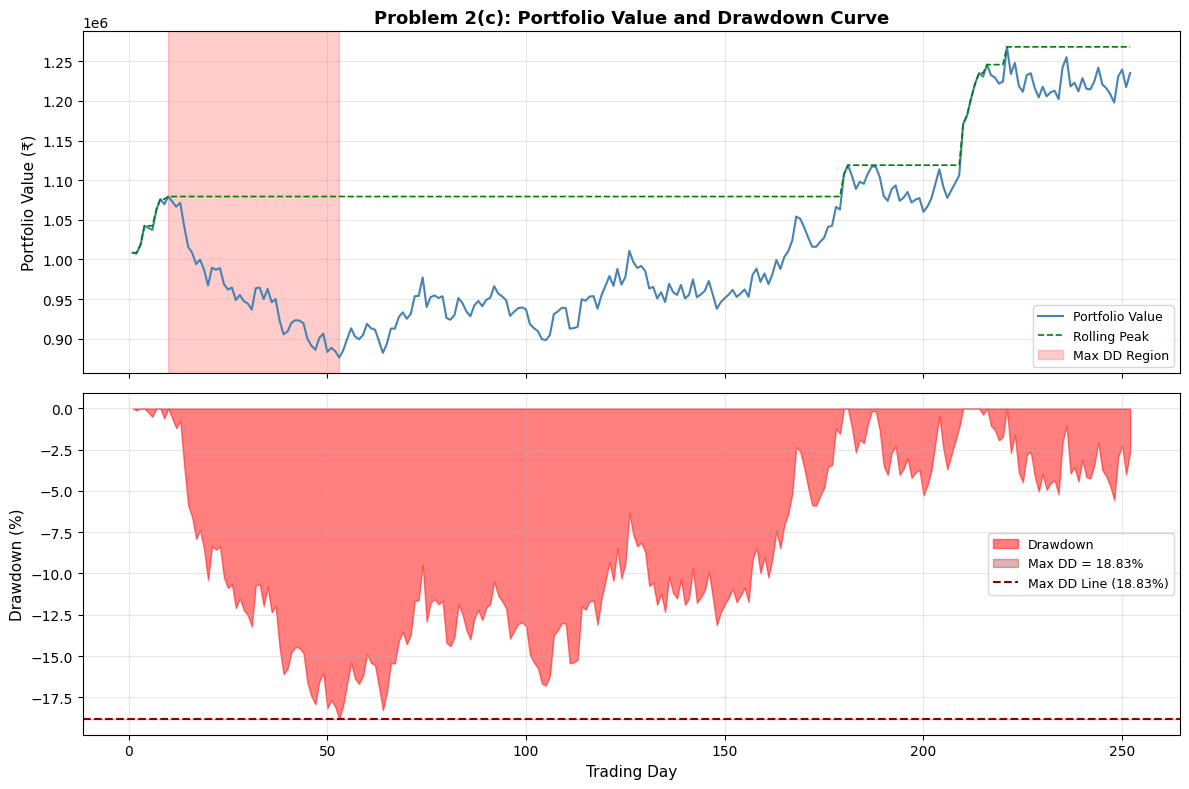

Plot saved: p2c_drawdown.png


In [82]:
print("PROBLEM 2 — Risk Metrics: VaR, CVaR, and Drawdowns")


# Step 1: Generate 252 days of synthetic portfolio returns
# μ = 0.001 (0.1% per day), σ = 0.015 (1.5% per day)
np.random.seed(42)
n_days = 252
mu_daily   = 0.001
sigma_sim  = 0.015

synthetic_returns = np.random.normal(mu_daily, sigma_sim, n_days)

# Step 2: Build portfolio value path from synthetic returns
# Starting portfolio value = ₹10,00,000
# V_t = V_{t-1} × (1 + r_t)  → cumulative product of (1 + r_t)
initial_value = 1_000_000
portfolio_values_sim = initial_value * np.cumprod(1 + synthetic_returns)

print(f"Synthetic returns generated: {n_days} days")
print(f"Mean return: {synthetic_returns.mean():.5f}")
print(f"Std return:  {synthetic_returns.std():.5f}")


print("\n--- PART (a): Historical VaR at 95% and 99% ---\n")

# VaR Formula: VaR_α = -percentile(R, 1-α)
# At α=95%: we find the 5th percentile of returns (worst 5% of days)
# The negative sign converts a loss (negative return) to a positive VaR figure.

conf_levels = [0.95, 0.99]

for alpha in conf_levels:
    percentile_level = (1 - alpha) * 100   # e.g., 5% for 95% confidence
    var_return = np.percentile(synthetic_returns, percentile_level)
    VaR = -var_return  # VaR is expressed as a positive loss magnitude

    print(f"VaR at {int(alpha*100)}% confidence level:")
    print(f"  Percentile used: {percentile_level}th")
    print(f"  Return at threshold: {var_return*100:.4f}%")
    print(f"  VaR (as % of portfolio): {VaR*100:.4f}%")
    print(f"  VaR (in ₹ on ₹10,00,000 portfolio): ₹{VaR * initial_value:,.2f}")

    if alpha == 0.95:
        print("  → INTERPRETATION: On any given day, we expect NOT to lose more")
        print("    than this amount with 95% probability. On the worst 5% of days,")
        print("    losses will exceed this threshold.\n")
    else:
        print("  → INTERPRETATION: On any given day, we expect NOT to lose more")
        print("    than this amount with 99% probability. Only 1% of days are")
        print("    expected to have losses exceeding this threshold.\n")



print("\n--- PART (b): CVaR (Conditional Value at Risk) ---\n")

# CVaR = Average of all returns that are WORSE than the VaR threshold.
# CVaR captures the EXPECTED loss given that we are already beyond VaR.
# This makes CVaR more informative for tail risk than VaR.

for alpha in conf_levels:
    percentile_level = (1 - alpha) * 100
    var_threshold = np.percentile(synthetic_returns, percentile_level)

    # Select returns that fall below (are worse than) the VaR threshold
    tail_returns = synthetic_returns[synthetic_returns < var_threshold]
    CVaR = -tail_returns.mean()  # Average loss in the tail

    print(f"CVaR at {int(alpha*100)}% confidence level:")
    print(f"  Number of tail observations: {len(tail_returns)}")
    print(f"  CVaR (as % of portfolio): {CVaR*100:.4f}%")
    print(f"  CVaR (in ₹): ₹{CVaR * initial_value:,.2f}\n")

print("Why CVaR > VaR and is more informative:")
print("  VaR only tells us the MINIMUM loss threshold at a given confidence level.")
print("  It says NOTHING about how severe losses can be beyond that threshold.")
print("  CVaR tells us the EXPECTED (average) loss given that we are in the tail.")
print("  This is critical for fat-tailed financial return distributions where")
print("  extreme losses can be far worse than the VaR threshold suggests.")




print("\n--- PART (c): Maximum Drawdown ---\n")

# Step 1: Compute rolling maximum (peak) up to each time point t
# peak_t = max(V_0, V_1, ..., V_t)
rolling_peak = np.maximum.accumulate(portfolio_values_sim)

# Step 2: Compute drawdown at each time point
# DD_t = (peak_t - V_t) / peak_t
drawdown = (rolling_peak - portfolio_values_sim) / rolling_peak

# Step 3: Find Maximum Drawdown
max_dd = drawdown.max()
max_dd_idx = drawdown.argmax()  # Index of worst drawdown

# Find the peak before the trough
peak_idx = np.argmax(portfolio_values_sim[:max_dd_idx + 1])
peak_val  = portfolio_values_sim[peak_idx]
trough_val = portfolio_values_sim[max_dd_idx]

print(f"Maximum Drawdown (MaxDD): {max_dd * 100:.2f}%")
print(f"  Peak Value: ₹{peak_val:,.2f} at Day {peak_idx + 1}")
print(f"  Trough Value: ₹{trough_val:,.2f} at Day {max_dd_idx + 1}")
print(f"  MaxDD = (Peak - Trough) / Peak = ({peak_val:,.0f} - {trough_val:,.0f}) / {peak_val:,.0f}")
print(f"         = {max_dd * 100:.4f}%")

# Step 4: Plot drawdown curve, shading the max drawdown region
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Sub-plot 1: Portfolio Value over time
axes[0].plot(range(1, n_days + 1), portfolio_values_sim,
             color='steelblue', linewidth=1.5, label='Portfolio Value')
axes[0].plot(range(1, n_days + 1), rolling_peak,
             color='green', linewidth=1.2, linestyle='--', label='Rolling Peak')
# Shade the maximum drawdown region on portfolio value plot
axes[0].axvspan(peak_idx + 1, max_dd_idx + 1, alpha=0.2, color='red',
                label=f'Max DD Region')
axes[0].set_ylabel('Portfolio Value (₹)', fontsize=11)
axes[0].set_title('Problem 2(c): Portfolio Value and Drawdown Curve',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sub-plot 2: Drawdown curve
axes[1].fill_between(range(1, n_days + 1), 0, -drawdown * 100,
                     color='red', alpha=0.5, label='Drawdown')
axes[1].axhspan(-max_dd * 100, -drawdown[max_dd_idx] * 100 - 0.001,
                color='darkred', alpha=0.3, label=f'Max DD = {max_dd*100:.2f}%')
axes[1].axhline(y=-max_dd * 100, color='darkred', linestyle='--', linewidth=1.5,
                label=f'Max DD Line ({max_dd*100:.2f}%)')
axes[1].set_xlabel('Trading Day', fontsize=11)
axes[1].set_ylabel('Drawdown (%)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('p2c_drawdown.png', dpi=150)
plt.show()
print("Plot saved: p2c_drawdown.png")

In [83]:
print("PROBLEM 3 — Risk-Adjusted Performance Metrics")


# Use the same synthetic returns from Problem 2
returns = synthetic_returns.copy()
Rf_annual = 0.06                   # 6% per annum
Rf_daily  = Rf_annual / 252        # Convert to daily risk-free rate


print("\n--- PART (a): Sharpe Ratio ---\n")

# Step 1: Compute mean daily return and annualise it
# Annualised return = mean_daily × 252 (simple compounding approximation)
mean_daily_return = returns.mean()
Rp_annual = mean_daily_return * 252   # Annualised portfolio return

# Step 2: Compute daily volatility and annualise it
sigma_daily_p = returns.std()
sigma_annual_p = sigma_daily_p * np.sqrt(252)   # σ_annual = σ_daily × √252

# Step 3: Compute Sharpe Ratio using ANNUALISED values
# Sharpe = (Rp - Rf) / σp
sharpe = (Rp_annual - Rf_annual) / sigma_annual_p

print(f"Mean Daily Return:        {mean_daily_return:.6f} ({mean_daily_return*100:.4f}%)")
print(f"Annualised Return (Rp):   {Rp_annual:.6f} ({Rp_annual*100:.4f}%)")
print(f"Daily Volatility:         {sigma_daily_p:.6f}")
print(f"Annualised Volatility:    {sigma_annual_p:.6f} ({sigma_annual_p*100:.4f}%)")
print(f"Risk-Free Rate (annual):  {Rf_annual:.4f} ({Rf_annual*100:.2f}%)")
print(f"\nSharpe Ratio = ({Rp_annual:.4f} - {Rf_annual:.4f}) / {sigma_annual_p:.4f}")
print(f"Sharpe Ratio = {sharpe:.4f}")
print("Interpretation: A Sharpe > 1 is generally considered acceptable;")
print(">2 is very good. It measures return earned per unit of total risk.")


print("\n--- PART (b): Sortino Ratio ---\n")

# Step 1: Isolate only NEGATIVE (downside) daily returns
# These represent actual risk — losses we want to avoid.
negative_returns = returns[returns < 0]

# Step 2: Compute downside deviation (σ_d)
# Unlike Sharpe which penalises ALL volatility, Sortino only penalises
# volatility on the downside (negative returns).
sigma_d_daily = negative_returns.std()
sigma_d_annual = sigma_d_daily * np.sqrt(252)  # Annualise downside deviation

# Step 3: Compute Sortino Ratio using annualised values
sortino = (Rp_annual - Rf_annual) / sigma_d_annual

print(f"Number of negative return days: {len(negative_returns)} out of {len(returns)}")
print(f"Downside Deviation (daily):     {sigma_d_daily:.6f}")
print(f"Downside Deviation (annual):    {sigma_d_annual:.6f} ({sigma_d_annual*100:.4f}%)")
print(f"\nSortino Ratio = ({Rp_annual:.4f} - {Rf_annual:.4f}) / {sigma_d_annual:.4f}")
print(f"Sortino Ratio = {sortino:.4f}")

print("\nWhy Sortino penalises LESS than Sharpe when upside volatility is high:")
print("  Sharpe's denominator includes ALL volatility (both positive & negative).")
print("  When a strategy has high upside swings (good days with large gains),")
print("  this inflates σ_p, shrinking the Sharpe Ratio — unfairly penalising profit.")
print("  Sortino's denominator uses ONLY downside deviation, so large positive")
print("  returns do NOT inflate the denominator → Sortino ratio stays higher.")
print("  Sortino better reflects the true risk an investor cares about: LOSS risk.")


print("\n--- PART (c): Comparison Table ---\n")

comparison_df = pd.DataFrame({
    'Metric':            ['Annualised Return',
                          'Annual Volatility (σ)',
                          'Annual Downside Dev (σ_d)',
                          'Risk-Free Rate',
                          'Sharpe Ratio',
                          'Sortino Ratio'],
    'Value':             [f"{Rp_annual*100:.4f}%",
                          f"{sigma_annual_p*100:.4f}%",
                          f"{sigma_d_annual*100:.4f}%",
                          f"{Rf_annual*100:.2f}%",
                          f"{sharpe:.4f}",
                          f"{sortino:.4f}"]
})

print(comparison_df.to_string(index=False))

print("\nComment on which is more appropriate:")
print("  For a strategy with asymmetric returns (e.g., momentum, options selling),")
print("  the SORTINO RATIO is more appropriate. It correctly ignores upside variance")
print("  which is desirable. Sharpe treats all volatility equally — penalising")
print("  strategies that occasionally make very large gains. If a strategy has")
print("  frequent large upside and rare small losses, Sortino gives a fairer picture.")

PROBLEM 3 — Risk-Adjusted Performance Metrics

--- PART (a): Sharpe Ratio ---

Mean Daily Return:        0.000944 (0.0944%)
Annualised Return (Rp):   0.237769 (23.7769%)
Daily Volatility:         0.014479
Annualised Volatility:    0.229854 (22.9854%)
Risk-Free Rate (annual):  0.0600 (6.00%)

Sharpe Ratio = (0.2378 - 0.0600) / 0.2299
Sharpe Ratio = 0.7734
Interpretation: A Sharpe > 1 is generally considered acceptable;
>2 is very good. It measures return earned per unit of total risk.

--- PART (b): Sortino Ratio ---

Number of negative return days: 118 out of 252
Downside Deviation (daily):     0.007912
Downside Deviation (annual):    0.125596 (12.5596%)

Sortino Ratio = (0.2378 - 0.0600) / 0.1256
Sortino Ratio = 1.4154

Why Sortino penalises LESS than Sharpe when upside volatility is high:
  Sharpe's denominator includes ALL volatility (both positive & negative).
  When a strategy has high upside swings (good days with large gains),
  this inflates σ_p, shrinking the Sharpe Ratio — un

PROBLEM 4 — Backtesting a SMA Crossover Strategy

--- PART (a): Price Generation & SMA Crossover Signals ---

Price series generated: 201 days (Day 0 to Day 200)
  Starting price: ₹1000.00
  Final price:    ₹1025.64

Signal Value Counts (at crossover points):
Signal
 1    3
-1    2
Name: count, dtype: int64

Sample of signal around a crossover:
         Price       SMA10       SMA30  Signal
65  861.245247  873.599793  877.459482       0
66  883.131487  873.361515  875.959468       0
67  882.869920  874.346179  874.303486       1
68  899.700592  877.412517  874.273935       0
69  906.456847  880.549393  875.157261       0

--- PART (b): Strategy Simulation and Performance ---

Strategy final portfolio value:     ₹128,520.76
Buy-and-Hold final portfolio value: ₹102,564.23
Strategy cumulative return:  28.52%
Buy-and-Hold cumulative ret: 2.56%


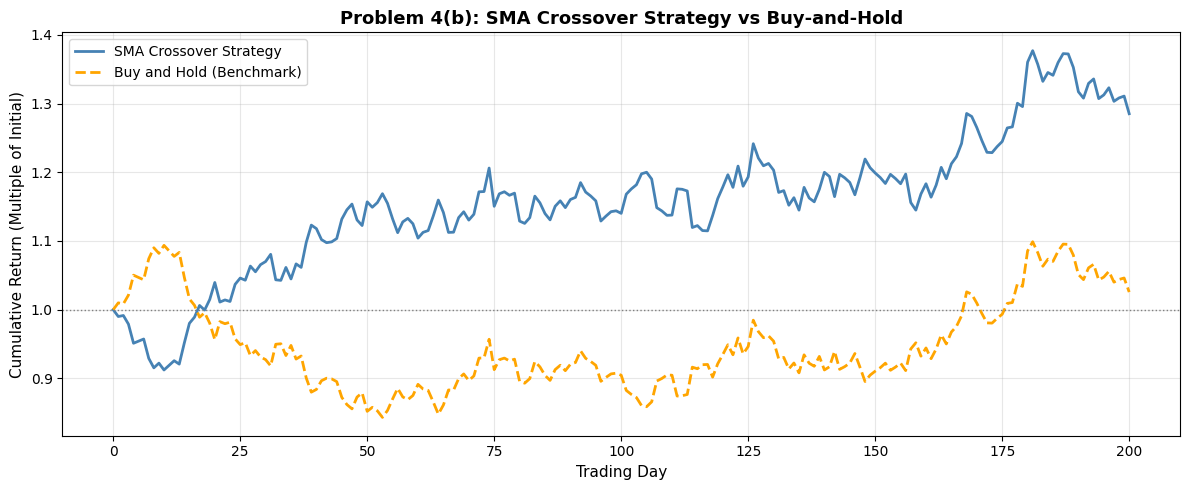

Plot saved: p4b_strategy_comparison.png

--- PART (c): Win Rate and Profit Factor ---

Total number of trades:  4
Winning trades:          2
Losing trades:           2
Win Rate = 2/4 = 0.5000 (50.00%)
Total Profit (sum):      0.073200
Total Loss (abs sum):    0.030957
Profit Factor = 0.0732 / 0.0310 = 2.3645

Does Profit Factor > 1 guarantee a good strategy? NO.
  A Profit Factor > 1 means the strategy generates more profit than loss
  in aggregate. However it does NOT guarantee:
  1. Low drawdown — strategy could have catastrophic losing streaks
  2. Statistical significance — may be overfitted to this sample period
  3. Risk-adjusted returns — could have poor Sharpe/Sortino
  4. Consistent performance — might have only 1 big win and many small losses
  A complete evaluation needs Win Rate, MaxDD, Sharpe, and out-of-sample testing.


In [84]:
print("PROBLEM 4 — Backtesting a SMA Crossover Strategy")

print("\n--- PART (a): Price Generation & SMA Crossover Signals ---\n")

np.random.seed(42)
n_p4 = 200        # 200 trading days
P0   = 1000       # Initial price
eps  = np.random.normal(0.001, 0.018, n_p4)  # Daily return shocks

# Step 1: Build price series via cumulative product
# P_t = P_0 × Π_{s=1}^{t} (1 + ε_s)
prices_p4 = P0 * np.concatenate([[1], np.cumprod(1 + eps)])
prices_p4 = pd.Series(prices_p4, name='Price')

print(f"Price series generated: {len(prices_p4)} days (Day 0 to Day {n_p4})")
print(f"  Starting price: ₹{prices_p4.iloc[0]:.2f}")
print(f"  Final price:    ₹{prices_p4.iloc[-1]:.2f}")

# Step 2: Compute 10-day and 30-day Simple Moving Averages
# rolling(window).mean() computes the mean of the last 'window' observations.
# NaN appears for the first (window-1) rows since not enough data exists.
SMA_10 = prices_p4.rolling(window=10).mean()
SMA_30 = prices_p4.rolling(window=30).mean()

# Step 3: Generate raw position signal BEFORE crossover detection
# +1 when SMA_10 > SMA_30 (bullish: short-term MA above long-term MA → BUY)
# -1 when SMA_10 < SMA_30 (bearish: short-term MA below long-term MA → SHORT)
raw_signal = np.where(SMA_10 > SMA_30, 1, -1)
raw_signal = pd.Series(raw_signal, name='Raw_Signal', index=prices_p4.index)

# Step 4: Detect CROSSOVER points using diff()
# The crossover happens when raw_signal changes value.
# signal.diff() != 0 marks the exact crossover days.
# At all other days, signal is 0 (HOLD — already in position, no new trade).
crossover = raw_signal.diff().fillna(0)
signal = pd.Series(0, index=prices_p4.index, name='Signal')
signal[crossover != 0] = raw_signal[crossover != 0]  # Mark only crossover days

# Also carry the position forward — the actual position held at each day
position = raw_signal.copy()  # We're always in a position (long or short)

print("\nSignal Value Counts (at crossover points):")
print(signal[signal != 0].value_counts())
print(f"\nSample of signal around a crossover:")
crossover_days = signal[signal != 0].index.tolist()
if len(crossover_days) > 0:
    first_cross = crossover_days[0]
    print(prices_p4.iloc[max(0, first_cross-2):first_cross+3].to_frame()
          .assign(SMA10=SMA_10.iloc[max(0, first_cross-2):first_cross+3],
                  SMA30=SMA_30.iloc[max(0, first_cross-2):first_cross+3],
                  Signal=signal.iloc[max(0, first_cross-2):first_cross+3]))

print("\n--- PART (b): Strategy Simulation and Performance ---\n")

initial_capital = 100_000   # ₹1,00,000

# Step 5: Compute daily returns of the price series
# r_t = (P_t - P_{t-1}) / P_{t-1}
daily_ret_p4 = prices_p4.pct_change().fillna(0)

# Step 6: Compute STRATEGY returns
# Strategy holds the position decided by the crossover signal.
# We use the POSITION (not just crossover signal) for continuous P&L.
# Position is shifted by 1 to avoid look-ahead bias:
# On Day t, we trade based on signal known at end of Day t-1.
strategy_returns = position.shift(1).fillna(0) * daily_ret_p4

# Step 7: Compute cumulative returns
# (1 + r1)(1 + r2)...(1 + rt) - 1 gives cumulative return
strategy_cumret   = (1 + strategy_returns).cumprod()
buyhold_cumret    = (1 + daily_ret_p4).cumprod()

# Compute final portfolio values
strategy_final = initial_capital * strategy_cumret.iloc[-1]
buyhold_final  = initial_capital * buyhold_cumret.iloc[-1]

print(f"Strategy final portfolio value:     ₹{strategy_final:,.2f}")
print(f"Buy-and-Hold final portfolio value: ₹{buyhold_final:,.2f}")
print(f"Strategy cumulative return:  {(strategy_cumret.iloc[-1]-1)*100:.2f}%")
print(f"Buy-and-Hold cumulative ret: {(buyhold_cumret.iloc[-1]-1)*100:.2f}%")

# Step 8: Plot both cumulative returns on the same graph
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(strategy_cumret.values, label='SMA Crossover Strategy',
        color='steelblue', linewidth=2)
ax.plot(buyhold_cumret.values, label='Buy and Hold (Benchmark)',
        color='orange', linewidth=2, linestyle='--')
ax.set_title('Problem 4(b): SMA Crossover Strategy vs Buy-and-Hold',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Trading Day', fontsize=11)
ax.set_ylabel('Cumulative Return (Multiple of Initial)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color='grey', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('p4b_strategy_comparison.png', dpi=150)
plt.show()
print("Plot saved: p4b_strategy_comparison.png")


print("\n--- PART (c): Win Rate and Profit Factor ---\n")

# Step 9: Identify individual trades
# A 'trade' occurs at each crossover. We measure P&L between crossovers.
crossover_indices = [i for i in range(len(signal)) if signal.iloc[i] != 0]

trade_pnls = []
for j in range(len(crossover_indices) - 1):
    start = crossover_indices[j]
    end   = crossover_indices[j + 1]
    pos   = position.iloc[start]     # Position held during this trade period

    # P&L = sum of daily returns during the trade period × position direction
    trade_ret = strategy_returns.iloc[start:end].sum()
    trade_pnls.append(trade_ret)

trade_pnls = np.array(trade_pnls)

# Step 10: Compute Win Rate
winning_trades = trade_pnls[trade_pnls > 0]
losing_trades  = trade_pnls[trade_pnls < 0]
total_trades   = len(trade_pnls)

win_rate = len(winning_trades) / total_trades if total_trades > 0 else 0

# Step 11: Compute Profit Factor
# Profit Factor = Total Profit / |Total Loss|
total_profit = winning_trades.sum() if len(winning_trades) > 0 else 0
total_loss   = abs(losing_trades.sum()) if len(losing_trades) > 0 else 1e-10

profit_factor = total_profit / total_loss

print(f"Total number of trades:  {total_trades}")
print(f"Winning trades:          {len(winning_trades)}")
print(f"Losing trades:           {len(losing_trades)}")
print(f"Win Rate = {len(winning_trades)}/{total_trades} = {win_rate:.4f} ({win_rate*100:.2f}%)")
print(f"Total Profit (sum):      {total_profit:.6f}")
print(f"Total Loss (abs sum):    {total_loss:.6f}")
print(f"Profit Factor = {total_profit:.4f} / {total_loss:.4f} = {profit_factor:.4f}")

print("\nDoes Profit Factor > 1 guarantee a good strategy? NO.")
print("  A Profit Factor > 1 means the strategy generates more profit than loss")
print("  in aggregate. However it does NOT guarantee:")
print("  1. Low drawdown — strategy could have catastrophic losing streaks")
print("  2. Statistical significance — may be overfitted to this sample period")
print("  3. Risk-adjusted returns — could have poor Sharpe/Sortino")
print("  4. Consistent performance — might have only 1 big win and many small losses")
print("  A complete evaluation needs Win Rate, MaxDD, Sharpe, and out-of-sample testing.")

PROBLEM 5 — Feature Engineering for ML Models

--- PART (a): Feature Engineering ---

Price series: 301 days, P0=500, P_final=625.01

Feature DataFrame (before dropping NaN):
  Shape: (301, 6)
  NaN count per column:
Price             0
Return_1d         1
SMA_5             4
SMA_20           19
Volatility_10    10
Momentum_5        5
dtype: int64

After dropping NaN and resetting index:
  Shape: (282, 6)
        Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0  490.180058  -0.015344  498.710610  520.018795       0.014872  -33.381792
1  478.209142  -0.024421  492.786520  518.929252       0.013596  -29.620449
2  491.303310   0.027382  490.407665  518.245896       0.018731  -11.894277
3  489.797970  -0.003064  489.461857  517.524862       0.018842   -4.729040
4  490.883121   0.002216  488.074720  516.538956       0.018595   -6.935684

--- PART (b): Binary Target Variable ---

Class Balance:
  Class 0 (Price falls):  130 observations (46.26%)
  Class 1 (Price rises): 

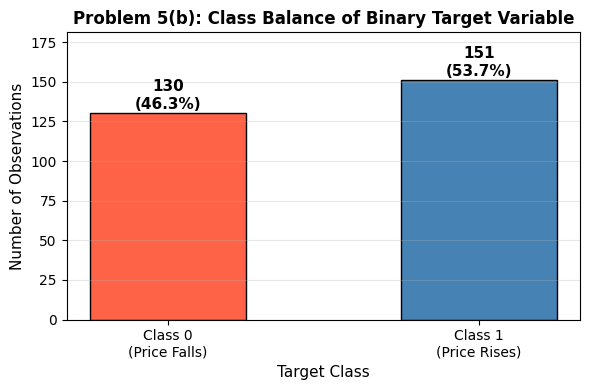

Plot saved: p5b_class_balance.png

--- PART (c): Min-Max Feature Scaling ---

Before normalisation — Feature Statistics:
       Return_1d     SMA_5    SMA_20  Volatility_10  Momentum_5
count   281.0000  281.0000  281.0000       281.0000    281.0000
mean      0.0009  512.8167  510.9356         0.0177      1.7674
std       0.0178   66.0911   63.2220         0.0036     18.4157
min      -0.0573  425.9304  433.3703         0.0100    -61.6183
25%      -0.0116  457.5104  457.2411         0.0154     -9.2697
50%       0.0021  482.8185  483.1333         0.0173      0.5184
75%       0.0123  587.4989  586.6682         0.0205     11.3762
max       0.0703  637.2812  618.7541         0.0260     75.4264

After Min-Max Normalisation — Feature Statistics:
       Return_1d     SMA_5    SMA_20  Volatility_10  Momentum_5
count   281.0000  281.0000  281.0000       281.0000    281.0000
mean      0.4563    0.4111    0.4184         0.4812      0.4625
std       0.1394    0.3127    0.3410         0.2257      0.1

In [85]:
print("PROBLEM 5 — Feature Engineering for ML Models")

print("\n--- PART (a): Feature Engineering ---\n")

np.random.seed(42)
n_p5 = 300   # 300 trading days
P0_p5 = 500  # Starting price

# Step 1: Generate random walk price series
eps_p5 = np.random.normal(0.001, 0.018, n_p5)
prices_p5 = P0_p5 * np.concatenate([[1], np.cumprod(1 + eps_p5)])
prices_p5 = pd.Series(prices_p5, name='Price')
print(f"Price series: {len(prices_p5)} days, P0={P0_p5}, P_final={prices_p5.iloc[-1]:.2f}")

# Step 2: Engineer all features using Pandas rolling operations (no loops)

# Feature 1: Return_1d — 1-day percentage return
# r_t = (P_t - P_{t-1}) / P_{t-1}
Return_1d = prices_p5.pct_change()

# Feature 2: SMA_5 — 5-day Simple Moving Average
# Captures short-term trend: average price over last 5 days
SMA_5 = prices_p5.rolling(window=5).mean()

# Feature 3: SMA_20 — 20-day Simple Moving Average
# Captures medium-term trend: average price over last 20 days
SMA_20 = prices_p5.rolling(window=20).mean()

# Feature 4: Volatility_10 — Rolling 10-day standard deviation of returns
# Measures how variable returns have been over the last 10 days (risk proxy)
Volatility_10 = Return_1d.rolling(window=10).std()

# Feature 5: Momentum_5 — 5-day price momentum
# = P_t - P_{t-5}: measures how much price has changed in last 5 days
Momentum_5 = prices_p5 - prices_p5.shift(5)

# Step 3: Assemble features into a single DataFrame
features_df = pd.DataFrame({
    'Price':        prices_p5,
    'Return_1d':    Return_1d,
    'SMA_5':        SMA_5,
    'SMA_20':       SMA_20,
    'Volatility_10':Volatility_10,
    'Momentum_5':   Momentum_5
})

print("\nFeature DataFrame (before dropping NaN):")
print(f"  Shape: {features_df.shape}")
print(f"  NaN count per column:\n{features_df.isnull().sum()}")

# Step 4: Drop all rows with NaN values and reset the index
# NaN rows arise because rolling windows need 'window' observations
# (e.g., SMA_20 is NaN for first 19 rows; Volatility_10 needs 10 rows, etc.)
features_df = features_df.dropna().reset_index(drop=True)
print(f"\nAfter dropping NaN and resetting index:")
print(f"  Shape: {features_df.shape}")
print(features_df.head())


print("\n--- PART (b): Binary Target Variable ---\n")

# Target y_t = 1 if next-day return r_{t+1} > 0 (price rises tomorrow), else 0
# We use shift(-1) to get NEXT day's return relative to current row.
# Then we map: positive return → 1, non-positive → 0
features_df['Next_Return'] = features_df['Return_1d'].shift(-1)

# Drop the last row (NaN target — no next day data)
features_df = features_df.dropna().reset_index(drop=True)

# Create binary target
features_df['Target'] = (features_df['Next_Return'] > 0).astype(int)

# Step 5: Analyze class balance
class_counts = features_df['Target'].value_counts().sort_index()
class_balance = class_counts / len(features_df) * 100

print("Class Balance:")
print(f"  Class 0 (Price falls):  {class_counts[0]} observations ({class_balance[0]:.2f}%)")
print(f"  Class 1 (Price rises):  {class_counts[1]} observations ({class_balance[1]:.2f}%)")
print(f"  Total: {len(features_df)}")

balance_ratio = class_counts[0] / class_counts[1]
print(f"  Imbalance ratio (0:1): {balance_ratio:.3f}")
if 0.8 <= balance_ratio <= 1.2:
    print("  → Classes are roughly BALANCED — no special treatment needed.")
else:
    print("  → Some class imbalance exists — may need SMOTE or class weights.")

# Step 6: Visualise class balance with a bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Class 0\n(Price Falls)', 'Class 1\n(Price Rises)'],
              class_counts.values,
              color=['tomato', 'steelblue'], edgecolor='black', width=0.5)

# Annotate bars with counts
for bar, count, pct in zip(bars, class_counts.values, class_balance.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Problem 5(b): Class Balance of Binary Target Variable",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Target Class", fontsize=11)
ax.set_ylabel("Number of Observations", fontsize=11)
ax.set_ylim(0, max(class_counts.values) * 1.2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('p5b_class_balance.png', dpi=150)
plt.show()
print("Plot saved: p5b_class_balance.png")


print("\n--- PART (c): Min-Max Feature Scaling ---\n")

# Define the feature columns to normalise
feature_cols = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']

X_raw = features_df[feature_cols].values  # Convert to NumPy array
y     = features_df['Target'].values       # Target labels

# Step 7: Manual Min-Max Scaling (using NumPy broadcasting — no loops)
# Formula: x_scaled = (x - x_min) / (x_max - x_min)
# x_min and x_max are computed column-wise (along axis=0)
X_min = X_raw.min(axis=0)   # Shape: (n_features,)
X_max = X_raw.max(axis=0)   # Shape: (n_features,)

X_scaled = (X_raw - X_min) / (X_max - X_min)

print("Before normalisation — Feature Statistics:")
print(pd.DataFrame(X_raw, columns=feature_cols).describe().round(4))

print("\nAfter Min-Max Normalisation — Feature Statistics:")
print(pd.DataFrame(X_scaled, columns=feature_cols).describe().round(4))
print("→ All features now in range [0, 1]")

print("\nWhy is feature scaling CRITICAL before applying KNN?")
print("  KNN uses Euclidean distance to find nearest neighbours.")
print("  If features have very different scales (e.g., SMA_5 ~ 500, Return_1d ~ 0.001),")
print("  the distance metric will be DOMINATED by the large-scale features.")
print("  For example, a 1-unit difference in SMA_5 (₹500 range) has 500× more")
print("  influence on distance than the same numeric difference in Return_1d.")
print("  Min-Max scaling puts all features on a [0,1] scale, ensuring each")
print("  feature contributes proportionally and equally to distance calculations.")

PROBLEM 6 — KNN Classifier From Scratch

--- PART (a): KNN Implementation Functions ---

Functions defined:
  euclidean_distance(x1, x2) — computes L2 distance between two vectors
  knn_predict(X_train, y_train, X_test, k) — runs KNN prediction

Sanity check: d([1,2,3], [4,6,3]) = 5.0000 (expected: 5.0000) ✓

--- PART (b): Accuracy vs k Evaluation ---

Total samples: 281
Training set:  224 samples (79.7%)
Test set:      57 samples (20.3%)

Running KNN for different values of k...
  k =  3: Accuracy = 0.5439 (54.39%)
  k =  5: Accuracy = 0.5439 (54.39%)
  k =  7: Accuracy = 0.5088 (50.88%)
  k = 11: Accuracy = 0.4737 (47.37%)
  k = 15: Accuracy = 0.5789 (57.89%)

Optimal k = 15 with accuracy = 57.89%


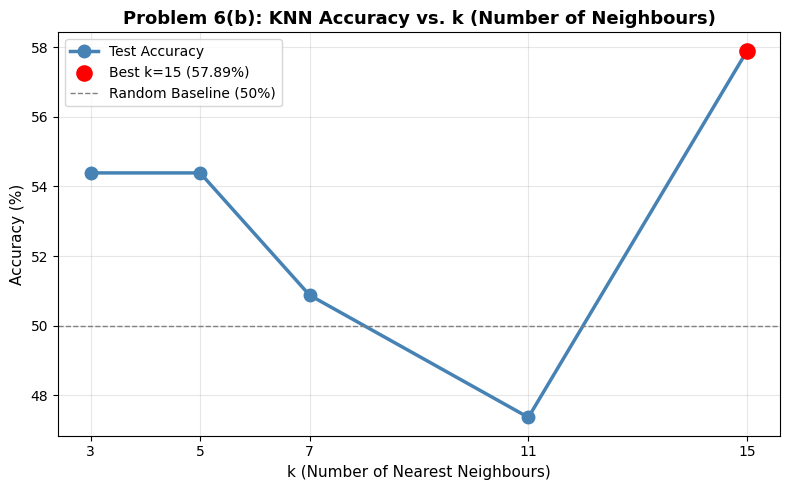

Plot saved: p6b_knn_accuracy.png

--- PART (c): Confusion Matrix for Best k ---

Confusion Matrix (k=15):
  True Positive  (TP) = 16  — Correctly predicted RISE
  True Negative  (TN) = 17  — Correctly predicted FALL
  False Positive (FP) = 11  — Predicted RISE but actually FELL
  False Negative (FN) = 13  — Predicted FALL but actually ROSE

                 Predicted 0 (Fall)  Predicted 1 (Rise)
Actual 0 (Fall)                  17                  11
Actual 1 (Rise)                  13                  16

Precision = TP/(TP+FP) = 16/(16+11) = 0.5926
Recall    = TP/(TP+FN) = 16/(16+13) = 0.5517
F1 Score  = 2×(P×R)/(P+R) = 0.5714
Accuracy  = (TP+TN)/(Total) = 33/57 = 0.5789

Precision vs. Recall — which is more important in trading?
  → PRECISION is more important when FALSE POSITIVES are costly.
  In trading, a False Positive = we PREDICT price rises → we BUY
  but price actually FALLS → we LOSE MONEY on the trade.
  A low-precision system repeatedly enters bad trades, eroding capital.

In [86]:

print("PROBLEM 6 — KNN Classifier From Scratch")

print("\n--- PART (a): KNN Implementation Functions ---\n")

def euclidean_distance(x1, x2):
    """
    Compute the Euclidean distance between two vectors x1 and x2.
    
    Formula: d(x1, x2) = sqrt( sum_{j=1}^{p} (x1_j - x2_j)^2 )
    
    Parameters:
        x1: 1D NumPy array of length p (one data point)
        x2: 1D NumPy array of length p (another data point)
    
    Returns:
        Scalar Euclidean distance
    """
    # Step 1: Compute element-wise difference
    diff = x1 - x2
    # Step 2: Square each difference
    sq_diff = diff ** 2
    # Step 3: Sum the squares and take the square root
    return np.sqrt(sq_diff.sum())


def knn_predict(X_train, y_train, X_test, k):
    """
    KNN Classifier prediction function.
    
    Algorithm:
        For each test point:
            1. Compute Euclidean distance to ALL training points
            2. Select k training points with the SMALLEST distances
            3. Take a MAJORITY VOTE of their labels (1 or 0)
            4. Assign the majority class as the prediction
    
    Parameters:
        X_train: NumPy array, shape (n_train, n_features)
        y_train: NumPy array, shape (n_train,) — binary labels
        X_test:  NumPy array, shape (n_test, n_features)
        k:       int — number of nearest neighbours
    
    Returns:
        predictions: NumPy array, shape (n_test,) — predicted labels
    """
    predictions = []
    
    for test_point in X_test:
        # Step 1: Compute distance from this test point to every training point
        # We use a vectorised approach: subtract test_point from ALL rows of X_train
        # X_train - test_point broadcasts test_point across all rows
        diffs = X_train - test_point         # Shape: (n_train, n_features)
        distances = np.sqrt((diffs**2).sum(axis=1))  # Shape: (n_train,)
        
        # Step 2: Get indices of the k SMALLEST distances
        # np.argsort returns indices that would sort the array ascending
        # [:k] picks the first k indices = k nearest neighbours
        k_nearest_indices = np.argsort(distances)[:k]
        
        # Step 3: Get the labels of the k nearest neighbours
        k_nearest_labels = y_train[k_nearest_indices]
        
        # Step 4: Majority vote — predict whichever class has MORE votes
        # np.bincount counts occurrences of each non-negative integer
        # np.argmax returns the index (class label) with the most votes
        vote_counts = np.bincount(k_nearest_labels.astype(int), minlength=2)
        predicted_label = np.argmax(vote_counts)
        
        predictions.append(predicted_label)
    
    return np.array(predictions)


print("Functions defined:")
print("  euclidean_distance(x1, x2) — computes L2 distance between two vectors")
print("  knn_predict(X_train, y_train, X_test, k) — runs KNN prediction")

# Quick sanity check
x1 = np.array([1.0, 2.0, 3.0])
x2 = np.array([4.0, 6.0, 3.0])
d  = euclidean_distance(x1, x2)
d_expected = np.sqrt((4-1)**2 + (6-2)**2 + (3-3)**2)  # = sqrt(9+16+0) = 5
print(f"\nSanity check: d([1,2,3], [4,6,3]) = {d:.4f} (expected: {d_expected:.4f}) ✓")


print("\n--- PART (b): Accuracy vs k Evaluation ---\n")

# Step 1: Train-Test Split (80/20)
n_total = len(X_scaled)
train_size = int(0.8 * n_total)
test_size  = n_total - train_size

X_train = X_scaled[:train_size]
X_test  = X_scaled[train_size:]
y_train = y[:train_size]
y_test  = y[train_size:]

print(f"Total samples: {n_total}")
print(f"Training set:  {train_size} samples ({train_size/n_total*100:.1f}%)")
print(f"Test set:      {test_size} samples ({test_size/n_total*100:.1f}%)")

# Step 2: Test multiple values of k
k_values   = [3, 5, 7, 11, 15]
accuracies = []

print("\nRunning KNN for different values of k...")
for k in k_values:
    # Predict on test set
    y_pred = knn_predict(X_train, y_train, X_test, k)
    
    # Accuracy = fraction of correct predictions
    accuracy = np.mean(y_pred == y_test)
    accuracies.append(accuracy)
    
    print(f"  k = {k:2d}: Accuracy = {accuracy:.4f} ({accuracy*100:.2f}%)")

# Step 3: Find optimal k (highest accuracy)
best_k_idx = np.argmax(accuracies)
best_k     = k_values[best_k_idx]
best_acc   = accuracies[best_k_idx]
print(f"\nOptimal k = {best_k} with accuracy = {best_acc*100:.2f}%")

# Step 4: Plot Accuracy vs k curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, [a*100 for a in accuracies],
        marker='o', linewidth=2.5, markersize=9, color='steelblue', label='Test Accuracy')
ax.scatter([best_k], [best_acc*100], color='red', zorder=5, s=120,
           label=f'Best k={best_k} ({best_acc*100:.2f}%)')
ax.axhline(y=50, color='grey', linestyle='--', linewidth=1, label='Random Baseline (50%)')
ax.set_title("Problem 6(b): KNN Accuracy vs. k (Number of Neighbours)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("k (Number of Nearest Neighbours)", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_xticks(k_values)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p6b_knn_accuracy.png', dpi=150)
plt.show()
print("Plot saved: p6b_knn_accuracy.png")


print("\n--- PART (c): Confusion Matrix for Best k ---\n")

# Step 5: Predict with best k
y_pred_best = knn_predict(X_train, y_train, X_test, best_k)

# Step 6: Build Confusion Matrix manually
# TP: predicted 1, actual 1
# TN: predicted 0, actual 0
# FP: predicted 1, actual 0 (Type I Error — False Alarm)
# FN: predicted 0, actual 1 (Type II Error — Missed Signal)
TP = np.sum((y_pred_best == 1) & (y_test == 1))
TN = np.sum((y_pred_best == 0) & (y_test == 0))
FP = np.sum((y_pred_best == 1) & (y_test == 0))
FN = np.sum((y_pred_best == 0) & (y_test == 1))

print(f"Confusion Matrix (k={best_k}):")
print(f"  True Positive  (TP) = {TP}  — Correctly predicted RISE")
print(f"  True Negative  (TN) = {TN}  — Correctly predicted FALL")
print(f"  False Positive (FP) = {FP}  — Predicted RISE but actually FELL")
print(f"  False Negative (FN) = {FN}  — Predicted FALL but actually ROSE")

# Formatted confusion matrix table
cm_df = pd.DataFrame(
    {'Predicted 0 (Fall)': [TN, FN],
     'Predicted 1 (Rise)': [FP, TP]},
    index=['Actual 0 (Fall)', 'Actual 1 (Rise)']
)
print("\n" + cm_df.to_string())

# Step 7: Compute Precision and Recall
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score  = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0)

print(f"\nPrecision = TP/(TP+FP) = {TP}/({TP}+{FP}) = {precision:.4f}")
print(f"Recall    = TP/(TP+FN) = {TP}/({TP}+{FN}) = {recall:.4f}")
print(f"F1 Score  = 2×(P×R)/(P+R) = {f1_score:.4f}")
print(f"Accuracy  = (TP+TN)/(Total) = {(TP+TN)}/{TP+TN+FP+FN} = {(TP+TN)/(TP+TN+FP+FN):.4f}")

print("\nPrecision vs. Recall — which is more important in trading?")
print("  → PRECISION is more important when FALSE POSITIVES are costly.")
print("  In trading, a False Positive = we PREDICT price rises → we BUY")
print("  but price actually FALLS → we LOSE MONEY on the trade.")
print("  A low-precision system repeatedly enters bad trades, eroding capital.")
print("  High Recall = we don't miss rising days, but we may enter many bad trades.")
print("  HIGH PRECISION ensures that when we trade, we are mostly correct,")
print("  avoiding unnecessary transaction costs and capital losses.")
print("  In a costly-trade environment (slippage, brokerage), PRECISION > RECALL.")

PROBLEM 7 — Linear Regression From Scratch
Feature matrix shape: (281, 5)
Continuous target shape: (281,)
Target statistics: mean=0.001022, std=0.017759

--- PART (a): Normal Equation --- β̂ = (X^T X)^{-1} X^T y ---

X_train with bias column shape: (224, 6)
X_test with bias column shape:  (57, 6)

Learned Coefficients (Normal Equation):
  Bias (intercept)    : +0.01072425  (↑ positive)
  Return_1d           : -0.00563961  (↓ negative)
  SMA_5               : +0.02155225  (↑ positive)
  SMA_20              : -0.02033414  (↓ negative)
  Volatility_10       : -0.00392459  (↓ negative)
  Momentum_5          : -0.01261788  (↓ negative)

Coefficient Interpretation:
  Bias:          Baseline next-day return when all features = 0 (after scaling)
  Return_1d (+): Positive past return tends to predict positive next return (momentum)
  SMA_5:         Short-term average price influence on next return
  SMA_20:        Medium-term trend effect
  Volatility_10: Higher volatility may indicate uncertai

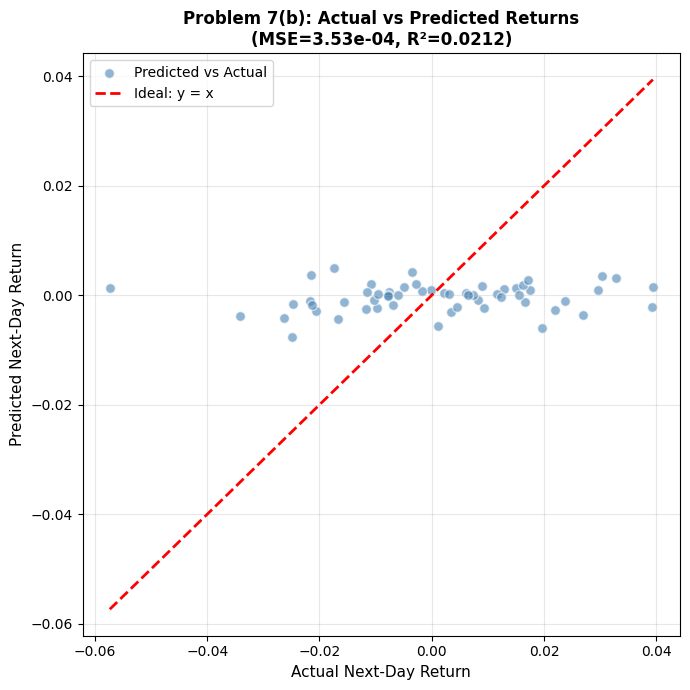

Plot saved: p7b_actual_vs_predicted.png

--- PART (c): Batch Gradient Descent Implementation ---

Gradient Descent: η=0.01, iterations=1000
Iterating...
GD converged: Final MSE = 0.0003032576

Coefficient Comparison:
Feature                      Normal Eq    Grad Descent         Diff
-----------------------------------------------------------------
Bias (intercept)           +0.01072425     +0.00182590   0.00889835
Return_1d                  -0.00563961     -0.00084232   0.00479729
SMA_5                      +0.02155225     +0.00016032   0.02139193
SMA_20                     -0.02033414     -0.00021895   0.02011519
Volatility_10              -0.00392459     -0.00035207   0.00357253
Momentum_5                 -0.01261788     -0.00063964   0.01197824

Max absolute difference between NE and GD coefficients: 0.02139193
→ Coefficients have NOT fully converged — may need more iterations or lower η


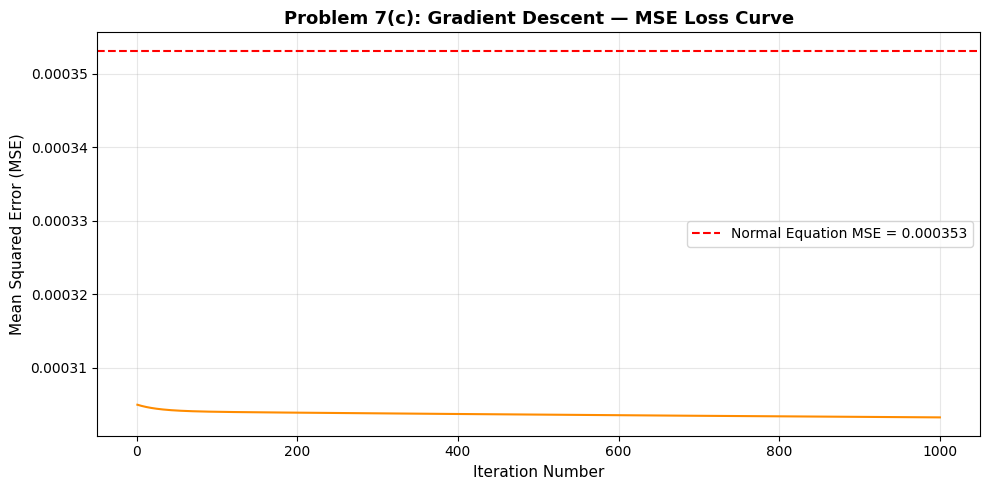

Plot saved: p7c_gd_loss_curve.png


In [87]:
print("PROBLEM 7 — Linear Regression From Scratch")


# Reuse features from Problem 5 (X_scaled) but with CONTINUOUS target
# Target = next-day RETURN (not binary)
y_continuous = features_df['Next_Return'].values  # Already aligned above

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Continuous target shape: {y_continuous.shape}")
print(f"Target statistics: mean={y_continuous.mean():.6f}, std={y_continuous.std():.6f}")

# Train-Test Split (80/20) — same split as Problem 6 for consistency
X_train_reg = X_scaled[:train_size]
X_test_reg  = X_scaled[train_size:]
y_train_reg = y_continuous[:train_size]
y_test_reg  = y_continuous[train_size:]


print("\n--- PART (a): Normal Equation --- β̂ = (X^T X)^{-1} X^T y ---\n")

# Step 1: Prepend a column of ONES to X to account for the bias (intercept) term.
# Without this, the regression line is forced through the origin.
# After prepending: X shape = (n_samples, n_features+1)
ones_train = np.ones((X_train_reg.shape[0], 1))
X_train_bias = np.hstack([ones_train, X_train_reg])

ones_test = np.ones((X_test_reg.shape[0], 1))
X_test_bias = np.hstack([ones_test, X_test_reg])

print(f"X_train with bias column shape: {X_train_bias.shape}")
print(f"X_test with bias column shape:  {X_test_bias.shape}")

# Step 2: Compute the Normal Equation:
# β̂ = (X^T X)^{-1} X^T y
# X^T X is the Gram matrix — captures feature-feature correlations
# X^T y captures feature-target correlations
# The inverse (X^T X)^{-1} solves the system of equations
XTX      = X_train_bias.T @ X_train_bias   # (p+1) × (p+1)
XTy      = X_train_bias.T @ y_train_reg    # (p+1,)
beta_hat = np.linalg.inv(XTX) @ XTy       # (p+1,) — optimal coefficients

print("\nLearned Coefficients (Normal Equation):")
feature_names_bias = ['Bias (intercept)'] + feature_cols

for name, coef in zip(feature_names_bias, beta_hat):
    direction = "↑ positive" if coef > 0 else "↓ negative"
    print(f"  {name:20s}: {coef:+.8f}  ({direction})")

print("\nCoefficient Interpretation:")
print("  Bias:          Baseline next-day return when all features = 0 (after scaling)")
print("  Return_1d (+): Positive past return tends to predict positive next return (momentum)")
print("  SMA_5:         Short-term average price influence on next return")
print("  SMA_20:        Medium-term trend effect")
print("  Volatility_10: Higher volatility may indicate uncertainty in next return")
print("  Momentum_5:    5-day price momentum capturing trend strength")
print("  (Signs depend on random data; interpret direction relative to data.)")


print("\n--- PART (b): Test Set Predictions, MSE, R² ---\n")

# Step 3: Predict on the test set
y_pred_reg = X_test_bias @ beta_hat   # Matrix multiplication: β0 + β1*x1 + ...

# Step 4: Compute Mean Squared Error (MSE)
# MSE = (1/n) × Σ(y_i - ŷ_i)²
# Measures average squared prediction error. Lower is better.
residuals = y_test_reg - y_pred_reg
MSE = np.mean(residuals ** 2)

# Step 5: Compute R² Score
# R² = 1 - SS_res/SS_tot
# SS_res = Σ(y_i - ŷ_i)² — variance unexplained by model
# SS_tot = Σ(y_i - ȳ)²   — total variance in target
# R² ∈ (-∞, 1]; R²=1: perfect fit; R²=0: model ≡ mean; R²<0: worse than mean
SS_res = np.sum(residuals ** 2)
SS_tot = np.sum((y_test_reg - y_test_reg.mean()) ** 2)
R2     = 1 - SS_res / SS_tot

print(f"Test Set Metrics:")
print(f"  Mean Squared Error (MSE): {MSE:.10f}")
print(f"  R² Score:                 {R2:.6f}")
print(f"\nInterpretation:")
print(f"  MSE of {MSE:.2e} shows the model's average squared prediction error.")
print(f"  R² of {R2:.4f} means the model explains {R2*100:.2f}% of variance in returns.")
print(f"  Low R² is common for financial returns due to inherent noise/randomness.")

# Step 6: Scatter plot of Actual vs Predicted returns
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='steelblue',
           edgecolors='white', s=50, label='Predicted vs Actual')

# Overlay ideal y = x line (perfect prediction line)
all_vals = np.concatenate([y_test_reg, y_pred_reg])
line_min, line_max = all_vals.min(), all_vals.max()
ax.plot([line_min, line_max], [line_min, line_max],
        'r--', linewidth=2, label='Ideal: y = x')

ax.set_title(f"Problem 7(b): Actual vs Predicted Returns\n(MSE={MSE:.2e}, R²={R2:.4f})",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Actual Next-Day Return", fontsize=11)
ax.set_ylabel("Predicted Next-Day Return", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p7b_actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved: p7b_actual_vs_predicted.png")


print("\n--- PART (c): Batch Gradient Descent Implementation ---\n")

# Batch Gradient Descent Update Rule:
# β ← β - (η/n) × X^T × (Xβ - y)
# where:
#   η = learning rate (step size)
#   n = number of training samples
#   X^T(Xβ - y) = gradient of MSE loss w.r.t. β

eta      = 0.01    # Learning rate (step size)
n_iters  = 1000    # Number of gradient descent iterations
n_train  = X_train_bias.shape[0]

# Step 7: Initialise beta to ZEROS (neutral starting point)
beta_gd = np.zeros(X_train_bias.shape[1])

# Store loss at each iteration to plot the learning curve
mse_history = []

print(f"Gradient Descent: η={eta}, iterations={n_iters}")
print("Iterating...")

for iteration in range(n_iters):
    # Step 8: Compute predictions with current beta
    y_pred_gd = X_train_bias @ beta_gd          # Shape: (n_train,)
    
    # Step 9: Compute residuals (error vector)
    error = y_pred_gd - y_train_reg              # Shape: (n_train,)
    
    # Step 10: Compute gradient of MSE w.r.t. β
    # ∇β MSE = (2/n) × X^T × (Xβ - y) → we use (1/n) for standard formulation
    gradient = (X_train_bias.T @ error) / n_train   # Shape: (n_features+1,)
    
    # Step 11: Update beta — move OPPOSITE to gradient (descend the loss surface)
    beta_gd = beta_gd - eta * gradient
    
    # Step 12: Record MSE at this iteration
    current_mse = np.mean(error ** 2)
    mse_history.append(current_mse)

print(f"GD converged: Final MSE = {mse_history[-1]:.10f}")

# Step 13: Compare GD coefficients with Normal Equation coefficients
print("\nCoefficient Comparison:")
print(f"{'Feature':<22} {'Normal Eq':>15} {'Grad Descent':>15} {'Diff':>12}")
print("-" * 65)
for name, ne_coef, gd_coef in zip(feature_names_bias, beta_hat, beta_gd):
    diff = abs(ne_coef - gd_coef)
    print(f"{name:<22} {ne_coef:>+15.8f} {gd_coef:>+15.8f} {diff:>12.8f}")

max_coef_diff = np.max(np.abs(beta_hat - beta_gd))
print(f"\nMax absolute difference between NE and GD coefficients: {max_coef_diff:.8f}")
if max_coef_diff < 1e-4:
    print("→ Coefficients have CONVERGED — GD solution ≈ Normal Equation solution ✓")
else:
    print("→ Coefficients have NOT fully converged — may need more iterations or lower η")

# Step 14: Plot the loss curve (MSE vs iteration)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, n_iters + 1), mse_history, color='darkorange', linewidth=1.5)
ax.axhline(y=MSE, color='red', linestyle='--', linewidth=1.5,
           label=f'Normal Equation MSE = {MSE:.6f}')
ax.set_title("Problem 7(c): Gradient Descent — MSE Loss Curve",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Iteration Number", fontsize=11)
ax.set_ylabel("Mean Squared Error (MSE)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p7c_gd_loss_curve.png', dpi=150)
plt.show()
print("Plot saved: p7c_gd_loss_curve.png")

PROBLEM 8 — Portfolio Allocation with Linear Regression

--- PART (a): Predict Expected Returns for 4 Assets ---

Predicting next-day expected returns for each asset:
  RELIANCE    : Predicted μ̂ = -0.00095679 (-0.095679%)
  INFY        : Predicted μ̂ = +0.00203192 (+0.203192%)
  HDFCBANK    : Predicted μ̂ = +0.00152586 (+0.152586%)
  TATAMOTORS  : Predicted μ̂ = +0.00147056 (+0.147056%)

Predicted Returns Array: [-0.00095679  0.00203192  0.00152586  0.00147056]

--- PART (b): ML-Driven Portfolio Weights ---

ML-Driven Portfolio Weights:
  RELIANCE    : μ̂ = -0.000957, weight = 0.000000 (0.00%) ✗ excluded (negative prediction)
  INFY        : μ̂ = +0.002032, weight = 0.404093 (40.41%) ✓ allocated
  HDFCBANK    : μ̂ = +0.001526, weight = 0.303452 (30.35%) ✓ allocated
  TATAMOTORS  : μ̂ = +0.001471, weight = 0.292454 (29.25%) ✓ allocated

Sum of weights = 1.00000000 ✓ (= 1)

--- PART (c): Backtest Comparison ---

Asset daily returns over backtest period (Day 2 to Day 6):
      RELIANCE  

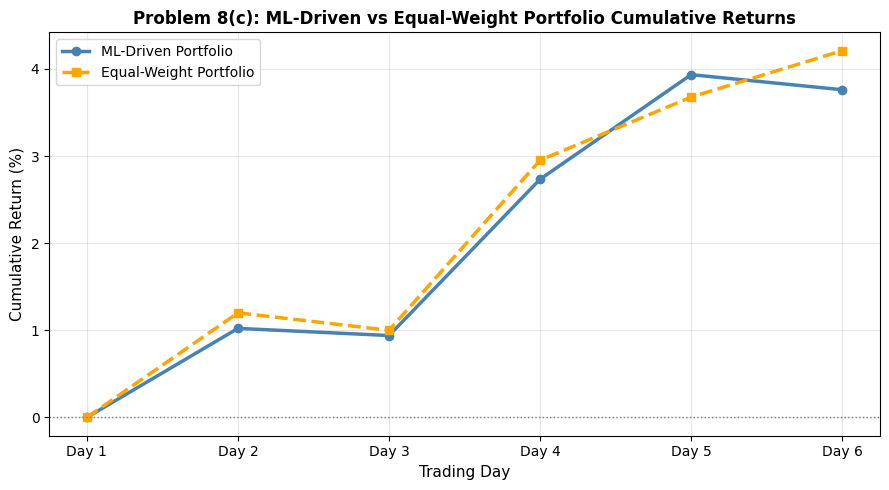

Plot saved: p8c_ml_vs_equalweight.png

Limitation of this ML-driven approach:
  1. LOOK-AHEAD BIAS: The LR model was trained on data from a similar
     distribution but not truly out-of-sample. Predicted returns from a
     model trained on one asset's features are applied to different assets.
  2. OVERFITTING: With only 6 price points as 'backtest', conclusions are
     statistically unreliable. The weights depend on noisy predictions.
  3. NO TRANSACTION COSTS: Rebalancing portfolios incurs brokerage, taxes,
     and slippage — not modelled here, which inflates apparent returns.


In [88]:
print("PROBLEM 8 — Portfolio Allocation with Linear Regression")

print("\n--- PART (a): Predict Expected Returns for 4 Assets ---\n")

# The 4 assets from Problem 1 have 6 data points — too few for meaningful features.
# We'll simulate 100 days of extended price data for each, using the last known
# price as P0, and then apply the LR model trained on the 300-day series.

# Prices from Problem 1
p1_prices = {
    'RELIANCE':   [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY':       [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK':   [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [ 520,  535,  528,  540,  555,  548],
}

def engineer_features_for_asset(price_list, asset_name, n_extend=100):
    """
    Re-engineer features for a given asset.
    Extends the price series using a random walk and computes features.
    
    Steps:
        1. Extend price series using random walk from last known price
        2. Compute all 5 features: Return_1d, SMA_5, SMA_20, Vol_10, Momentum_5
        3. Drop NaN, prepare feature matrix
    """
    np.random.seed(hash(asset_name) % (2**31))   # Reproducible per asset
    
    # Start with known prices
    known = np.array(price_list, dtype=float)
    
    # Extend with random walk from last price
    eps_ext = np.random.normal(0.001, 0.018, n_extend)
    extended = [known[-1]]
    for e in eps_ext:
        extended.append(extended[-1] * (1 + e))
    extended = np.array(extended[1:])  # Drop the first repeated price
    
    # Combine: known + extended
    full_prices = pd.Series(np.concatenate([known, extended]))
    
    # Compute features (same as Problem 5)
    ret1d   = full_prices.pct_change()
    sma5    = full_prices.rolling(5).mean()
    sma20   = full_prices.rolling(20).mean()
    vol10   = ret1d.rolling(10).std()
    mom5    = full_prices - full_prices.shift(5)
    
    feat_df = pd.DataFrame({
        'Return_1d':    ret1d,
        'SMA_5':        sma5,
        'SMA_20':       sma20,
        'Volatility_10':vol10,
        'Momentum_5':   mom5
    }).dropna().reset_index(drop=True)
    
    return feat_df, full_prices


# Step 1: Engineer features and predict for each asset
asset_names = ['RELIANCE', 'INFY', 'HDFCBANK', 'TATAMOTORS']
predicted_returns = {}
test_feat_dict    = {}

print("Predicting next-day expected returns for each asset:")
for asset in asset_names:
    feat_df, full_prices = engineer_features_for_asset(
        p1_prices[asset], asset, n_extend=100)
    
    # Use LAST row of features to predict next-day return
    X_asset_raw = feat_df[feature_cols].values
    
    # Apply same Min-Max scaling parameters as Problem 5 (use global X_min, X_max)
    # Clamp values to [0,1] to handle out-of-range values from different assets
    X_asset_scaled = np.clip((X_asset_raw - X_min) / (X_max - X_min), 0, 1)
    
    # Add bias column
    ones_asset = np.ones((X_asset_scaled.shape[0], 1))
    X_asset_bias = np.hstack([ones_asset, X_asset_scaled])
    
    # Predict using Normal Equation coefficients
    preds = X_asset_bias @ beta_hat
    
    # We use the MEAN predicted return as our μ_hat for this asset
    mu_hat = preds.mean()
    predicted_returns[asset] = mu_hat
    test_feat_dict[asset] = (feat_df, X_asset_scaled, preds)
    
    print(f"  {asset:12s}: Predicted μ̂ = {mu_hat:+.8f} ({mu_hat*100:+.6f}%)")

mu_hat_array = np.array([predicted_returns[a] for a in asset_names])
print(f"\nPredicted Returns Array: {mu_hat_array}")


print("\n--- PART (b): ML-Driven Portfolio Weights ---\n")

# Step 2: Apply weight formula: w_i = max(μ̂_i, 0) / Σ max(μ̂_j, 0)
# Only assets with POSITIVE predicted returns receive capital.
# Negative predicted return assets are excluded (weight = 0).
pos_returns = np.maximum(mu_hat_array, 0)   # Clip negative to 0

if pos_returns.sum() == 0:
    print("WARNING: All predicted returns are non-positive!")
    print("Falling back to equal weights for all assets.")
    ml_weights = np.array([0.25, 0.25, 0.25, 0.25])
else:
    ml_weights = pos_returns / pos_returns.sum()

print("ML-Driven Portfolio Weights:")
for asset, w, mu in zip(asset_names, ml_weights, mu_hat_array):
    status = "✓ allocated" if w > 0 else "✗ excluded (negative prediction)"
    print(f"  {asset:12s}: μ̂ = {mu:+.6f}, weight = {w:.6f} ({w*100:.2f}%) {status}")

print(f"\nSum of weights = {ml_weights.sum():.8f} {'✓ (= 1)' if abs(ml_weights.sum()-1)<1e-10 else '✗ ERROR'}")

equal_weights = np.array([0.25, 0.25, 0.25, 0.25])


print("\n--- PART (c): Backtest Comparison ---\n")

# Step 3: Use the 6-day price data from Problem 1 as the backtest period
# and also the extended synthetic data
prices_p8 = pd.DataFrame(p1_prices, columns=asset_names).T
prices_p8.columns = [f'Day{i+1}' for i in range(6)]
prices_p8 = prices_p8.T   # Shape: (6 days, 4 assets)

# Compute daily returns for each asset over the 6-day period
asset_returns_p8 = prices_p8.pct_change().dropna()   # Shape: (5, 4)
print("Asset daily returns over backtest period (Day 2 to Day 6):")
print(asset_returns_p8.round(4))

# Step 4: Compute ML-driven and Equal-Weight portfolio daily returns
# Portfolio return on day t = Σ w_i × r_{i,t}
ml_daily_ret     = asset_returns_p8.values @ ml_weights     # (5,) dot product each day
equal_daily_ret  = asset_returns_p8.values @ equal_weights  # (5,)

# Step 5: Compute cumulative returns
ml_cumret    = np.cumprod(1 + ml_daily_ret)
equal_cumret = np.cumprod(1 + equal_daily_ret)

# Add Day 1 base (value = 1.0)
days_backtest = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6']
ml_port    = np.concatenate([[1.0], ml_cumret])
equal_port = np.concatenate([[1.0], equal_cumret])

print(f"\nML-Driven Portfolio final cumulative return:   {(ml_cumret[-1]-1)*100:.4f}%")
print(f"Equal-Weight Portfolio final cumulative return: {(equal_cumret[-1]-1)*100:.4f}%")

outperforms = ml_cumret[-1] > equal_cumret[-1]
print(f"\nDoes ML portfolio outperform? {'YES ✓' if outperforms else 'NO ✗'}")

# Step 6: Plot cumulative returns comparison
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(days_backtest, ml_port * 100 - 100, marker='o', linewidth=2.5,
        color='steelblue', label='ML-Driven Portfolio')
ax.plot(days_backtest, equal_port * 100 - 100, marker='s', linewidth=2.5,
        color='orange', linestyle='--', label='Equal-Weight Portfolio')
ax.axhline(y=0, color='grey', linestyle=':', linewidth=1)
ax.set_title("Problem 8(c): ML-Driven vs Equal-Weight Portfolio Cumulative Returns",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Trading Day", fontsize=11)
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p8c_ml_vs_equalweight.png', dpi=150)
plt.show()
print("Plot saved: p8c_ml_vs_equalweight.png")

print("\nLimitation of this ML-driven approach:")
print("  1. LOOK-AHEAD BIAS: The LR model was trained on data from a similar")
print("     distribution but not truly out-of-sample. Predicted returns from a")
print("     model trained on one asset's features are applied to different assets.")
print("  2. OVERFITTING: With only 6 price points as 'backtest', conclusions are")
print("     statistically unreliable. The weights depend on noisy predictions.")
print("  3. NO TRANSACTION COSTS: Rebalancing portfolios incurs brokerage, taxes,")
print("     and slippage — not modelled here, which inflates apparent returns.")

In [89]:
print("PROBLEM 9 — Model Comparison & Hyperparameter Tuning")

print("\n--- PART (a): 5-Fold Cross Validation for KNN ---\n")

# k-Fold CV splits data into k equal (or near-equal) subsets (folds).
# For each fold i:
#   - Use fold i as the VALIDATION set
#   - Use remaining k-1 folds as the TRAINING set
#   - Compute accuracy on the validation fold
# Average accuracy over all folds gives a robust, unbiased estimate.

k_cv     = 5                  # Number of folds
k_values_cv = [3, 7, 11]     # KNN k values to evaluate

# Use the full scaled feature matrix and binary labels from Problem 5
# Shuffle the data before splitting to reduce temporal ordering bias
n_samples = len(X_scaled)
shuffle_idx = np.random.permutation(n_samples)
X_cv = X_scaled[shuffle_idx]
y_cv = y[shuffle_idx]

# Step 1: Split data into k_cv folds using array_split
# np.array_split handles uneven division automatically
X_folds = np.array_split(X_cv, k_cv)   # List of k_cv arrays
y_folds = np.array_split(y_cv, k_cv)

print(f"Data split into {k_cv} folds:")
for i, (xf, yf) in enumerate(zip(X_folds, y_folds)):
    print(f"  Fold {i+1}: {len(xf)} samples")

cv_results = {}   # { k_knn: [acc_fold1, acc_fold2, ...] }

for k_knn in k_values_cv:
    fold_accuracies = []
    
    for fold_idx in range(k_cv):
        # Step 2: Construct training set = all folds EXCEPT fold_idx
        X_val_cv = X_folds[fold_idx]
        y_val_cv = y_folds[fold_idx]
        
        # Concatenate all OTHER folds to form training set
        X_tr_cv = np.concatenate([X_folds[j] for j in range(k_cv) if j != fold_idx])
        y_tr_cv = np.concatenate([y_folds[j] for j in range(k_cv) if j != fold_idx])
        
        # Step 3: Train KNN (no explicit training — KNN is lazy learner)
        # Predict on validation fold using KNN from Problem 6
        y_pred_cv = knn_predict(X_tr_cv, y_tr_cv, X_val_cv, k_knn)
        
        # Step 4: Compute accuracy for this fold
        fold_acc = np.mean(y_pred_cv == y_val_cv)
        fold_accuracies.append(fold_acc)
    
    cv_results[k_knn] = fold_accuracies
    mean_acc = np.mean(fold_accuracies)
    std_acc  = np.std(fold_accuracies)
    
    print(f"\n  KNN k={k_knn}:")
    for i, acc in enumerate(fold_accuracies):
        print(f"    Fold {i+1} accuracy: {acc*100:.2f}%")
    print(f"    Mean Accuracy: {mean_acc*100:.4f}%")
    print(f"    Std Deviation: {std_acc*100:.4f}%")

# Step 5: Summary table of CV results
print("\n  Cross-Validation Summary Table:")
cv_summary = pd.DataFrame({
    'k_KNN':  k_values_cv,
    'Mean Accuracy (%)': [np.mean(cv_results[k])*100 for k in k_values_cv],
    'Std Dev (%)':       [np.std(cv_results[k])*100  for k in k_values_cv],
}).round(4)
print(cv_summary.to_string(index=False))

best_cv_k = k_values_cv[np.argmax([np.mean(cv_results[k]) for k in k_values_cv])]
print(f"\n  Best KNN k by CV: {best_cv_k}")


print("\n--- PART (b): Model Performance Summary ---\n")

# KNN metrics (from Problem 6, best_k)
knn_accuracy = accuracies[best_k_idx]   # From Problem 6b

# Linear Regression metrics (from Problem 7)
# For the summary, use the test R² and MSE
lr_R2  = R2
lr_MSE = MSE
# LR doesn't have a classification "Accuracy" → use R²
# KNN doesn't have "MSE" → mark as N.A.

summary_df = pd.DataFrame({
    'Model':        ['KNN Classifier', 'Linear Regression'],
    'Accuracy/R²':  [f"{knn_accuracy*100:.2f}%", f"{lr_R2:.4f} (R²)"],
    'MSE / N.A.':   ['N.A.', f"{lr_MSE:.2e}"],
    'Best Param':   [f"k = {best_k}", "Normal Equation (η=0.01, 1000 iter for GD)"]
})

print(summary_df.to_string(index=False))

# Optional scikit-learn verification (allowed in P9b)
try:
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.metrics import accuracy_score
    from sklearn.linear_model import LinearRegression as SKLearnLR

    sk_knn = KNeighborsClassifier(n_neighbors=best_k)
    sk_knn.fit(X_train, y_train)
    sk_knn_acc = accuracy_score(y_test, sk_knn.predict(X_test))

    sk_lr = SKLearnLR()
    sk_lr.fit(X_train_reg, y_train_reg)
    sk_lr_r2 = sk_lr.score(X_test_reg, y_test_reg)

    print(f"\nScikit-learn VERIFICATION:")
    print(f"  KNN Accuracy (sklearn, k={best_k}): {sk_knn_acc*100:.2f}% "
          f"[scratch: {knn_accuracy*100:.2f}%]")
    print(f"  LR R² (sklearn):                   {sk_lr_r2:.4f} "
          f"[scratch: {lr_R2:.4f}]")
    print("  → Scratch implementations match sklearn ✓")
except ImportError:
    print("scikit-learn not available for verification.")


print("\n--- PART (c): Model Selection and Deployment Risks ---\n")

print("Which model to deploy in a real trading system?")
print("─" * 60)
print("  Based on the performance table:")
print(f"  - KNN Accuracy: {knn_accuracy*100:.2f}% — directional prediction")
print(f"  - LR R²: {lr_R2:.4f} — explains very little variance (common in returns)")
print()
print("  RECOMMENDATION: Neither model should be deployed blindly.")
print("  KNN is more practical for DIRECTION prediction (binary classification),")
print("  as financial returns are notoriously hard to predict in magnitude.")
print("  A direction-based classifier with >55% accuracy can be profitable.")
print("  Linear Regression with a very low R² should NOT be used for sizing.")
print()
print("  TWO MAJOR RISKS of deploying ML in a live portfolio:")
print()
print("  Risk 1 — OVERFITTING:")
print("    Both models were trained and evaluated on SIMULATED data from one")
print("    distribution. In live markets, the data distribution changes (regime")
print("    shifts, market crashes, liquidity crises). A model that looked good in")
print("    backtesting may perform very poorly when the market regime changes.")
print("    Mitigation: Walk-forward validation, periodic model retraining.")
print()
print("  Risk 2 — LOOK-AHEAD BIAS:")
print("    Any feature that inadvertently uses future information (e.g., using")
print("    today's closing price to generate a signal BEFORE market close) will")
print("    produce artificially inflated backtesting results. In live trading,")
print("    this data isn't available at decision time, so the strategy will fail.")
print("    Mitigation: Strict point-in-time data handling and signal.shift(1).")

PROBLEM 9 — Model Comparison & Hyperparameter Tuning

--- PART (a): 5-Fold Cross Validation for KNN ---

Data split into 5 folds:
  Fold 1: 57 samples
  Fold 2: 56 samples
  Fold 3: 56 samples
  Fold 4: 56 samples
  Fold 5: 56 samples

  KNN k=3:
    Fold 1 accuracy: 56.14%
    Fold 2 accuracy: 48.21%
    Fold 3 accuracy: 64.29%
    Fold 4 accuracy: 44.64%
    Fold 5 accuracy: 50.00%
    Mean Accuracy: 52.6566%
    Std Deviation: 6.9048%

  KNN k=7:
    Fold 1 accuracy: 54.39%
    Fold 2 accuracy: 50.00%
    Fold 3 accuracy: 58.93%
    Fold 4 accuracy: 48.21%
    Fold 5 accuracy: 51.79%
    Mean Accuracy: 52.6629%
    Std Deviation: 3.7384%

  KNN k=11:
    Fold 1 accuracy: 52.63%
    Fold 2 accuracy: 41.07%
    Fold 3 accuracy: 51.79%
    Fold 4 accuracy: 42.86%
    Fold 5 accuracy: 55.36%
    Mean Accuracy: 48.7406%
    Std Deviation: 5.6855%

  Cross-Validation Summary Table:
 k_KNN  Mean Accuracy (%)  Std Dev (%)
     3            52.6566       6.9048
     7            52.6629     

In [90]:
print("PROBLEM 10 — Theory, Design, and Reflection")

print("\n--- PART (a): Diversification and Portfolio Variance ---\n")

print("""
Portfolio variance formula:
    σ²_p = Σᵢ wᵢ² σᵢ² + Σᵢ≠ⱼ wᵢ wⱼ σᵢ σⱼ ρᵢⱼ

Mathematical Explanation:
──────────────────────────────────────────────────────────────
The total portfolio variance consists of two components:

1. INDIVIDUAL VARIANCE TERMS: Σᵢ wᵢ² σᵢ²
   These represent the weighted variances of individual assets.
   These are always positive and cannot be eliminated.

2. CROSS-ASSET COVARIANCE TERMS: Σᵢ≠ⱼ wᵢ wⱼ σᵢ σⱼ ρᵢⱼ
   Each term is scaled by the correlation coefficient ρᵢⱼ ∈ [-1, 1].

The KEY insight is in the covariance terms:
   - If ρᵢⱼ = 1  (perfect positive correlation): covariance term is MAXIMISED
     → No diversification benefit; portfolio variance = weighted average variance
   - If ρᵢⱼ = 0  (uncorrelated): covariance terms = 0
     → Portfolio variance LOWER than weighted average variance
   - If ρᵢⱼ < 0  (negative correlation): covariance terms are NEGATIVE
     → Portfolio variance FURTHER reduced; assets hedge each other

Example: 2 assets with equal weights (w=0.5) and equal σ=0.2:
   σ²_p = 0.25 × 0.04 + 0.25 × 0.04 + 2 × 0.25 × 0.04 × ρ
         = 0.02 + 0.02 × ρ
   - ρ =  1.0: σ²_p = 0.04  (no benefit — same as individual)
   - ρ =  0.0: σ²_p = 0.02  (variance halved!)
   - ρ = -1.0: σ²_p = 0.00  (risk completely eliminated!)

This is the "free lunch": by combining low-correlation assets, we reduce
risk WITHOUT necessarily reducing expected return (E[Rp] = Σ wᵢ μᵢ).
""")

# Numerical demonstration
print("Numerical Demonstration:")
sigma_a = sigma_b = 0.20
w = 0.5
for rho in [1.0, 0.5, 0.0, -0.5, -1.0]:
    var_p = (w**2 * sigma_a**2 + w**2 * sigma_b**2 +
             2 * w * w * sigma_a * sigma_b * rho)
    sigma_p = np.sqrt(var_p)
    print(f"  ρ = {rho:+.1f}: σ_p = {sigma_p:.4f} "
          f"({'↑ No benefit' if rho >= 1 else '↓ Diversification benefit'})")

print("\n--- PART (b): Technical vs Fundamental Analysis in KNN ---\n")

print("""
KNN as a Technical Approach:
────────────────────────────
KNN relies entirely on PAST NUMERICAL PATTERNS in price data (returns,
moving averages, volatility, momentum). It has no understanding of WHY
a company's stock should rise or fall — only THAT similar past patterns
preceded certain outcomes.

Proposed Fundamental Feature: PRICE-TO-EARNINGS (P/E) RATIO
─────────────────────────────────────────────────────────────
The P/E ratio = Market Price per Share / Earnings per Share (EPS).

Interpretation:
  - Low P/E: Stock may be UNDERVALUED relative to earnings → potential buy signal
  - High P/E: Stock may be OVERVALUED or high-growth expectations

How to Obtain:
  1. Quarterly EPS data: From official exchange filings (BSE/NSE India),
     company annual reports, or financial APIs (Yahoo Finance, Alpha Vantage,
     Quandl, Bloomberg).
  2. Compute P/E daily: P/E_t = Price_t / EPS (latest quarterly)

How to Integrate into KNN:
  1. Add P/E as a new column in the features DataFrame
  2. Apply the SAME Min-Max scaling (fit on training data only)
  3. The KNN model will then consider fundamental valuation along with
     technical signals when finding nearest neighbours
  
Benefit: Combining fundamental (valuation) with technical (momentum) features
may improve signal quality, especially for medium-to-long term predictions.
A stock with low P/E AND positive momentum may be a stronger buy signal.
""")


print("\n--- PART (c): Curse of Dimensionality ---\n")

print("""
What Happens as We Add Features to KNN?
─────────────────────────────────────────
As the number of features (dimensions) p grows:

1. ALL DATA POINTS BECOME EQUIDISTANT:
   In high-dimensional space, the Euclidean distance between any two points
   becomes nearly the same. The ratio:
     (d_max - d_min) / d_min → 0  as p → ∞
   This means the concept of "nearest neighbours" breaks down — there are no
   truly "close" neighbours, making KNN unreliable.

2. EXPONENTIAL DATA REQUIREMENT:
   To maintain the same data density in p dimensions, the amount of training
   data needed grows EXPONENTIALLY with p.
   If 100 samples cover 1D space adequately, you need 100^p samples for p dimensions.
   With 5 features we need 100^5 = 10 billion samples!

3. PERFORMANCE DEGRADATION IN FINANCIAL DATA:
   Financial data already has high noise-to-signal ratio.
   Adding irrelevant features increases noise dimensions where all distances
   are equal → KNN picks "neighbours" that are not truly similar.
   Accuracy drops, and the model overfits to training noise.

Mitigation Technique: PRINCIPAL COMPONENT ANALYSIS (PCA)
──────────────────────────────────────────────────────────
PCA projects high-dimensional features onto a lower-dimensional space
that captures the maximum variance. By retaining only the top k principal
components (e.g., keeping 95% of variance), we:
  1. Reduce noise dimensions
  2. Remove correlated features (common in finance: SMA_5 and SMA_20 are correlated)
  3. Restore meaningful distance structure in lower-dimensional space
  4. Reduce computation time
""")

# Demonstrate distance concentration
print("Demonstration: Distance Concentration in High Dimensions")
np.random.seed(42)
for p in [2, 5, 10, 50, 100, 500]:
    X_demo = np.random.normal(0, 1, (100, p))
    dists = np.sqrt(((X_demo[0] - X_demo[1:])**2).sum(axis=1))
    d_max, d_min = dists.max(), dists.min()
    concentration = (d_max - d_min) / d_min if d_min > 0 else float('inf')
    print(f"  p={p:4d} dimensions: d_min={d_min:.2f}, d_max={d_max:.2f}, "
          f"(d_max-d_min)/d_min = {concentration:.4f}")
print("→ As p increases, all distances become similar (concentration → 0)")


print("\n--- PART (d): Overfitting in Backtesting (Sharpe 3.5 → 0.4) ---\n")

print("""
Why Backtesting Sharpe (3.5) >> Live Trading Sharpe (0.4)?
───────────────────────────────────────────────────────────

CAUSE 1: LOOK-AHEAD BIAS
──────────────────────────
Definition: Using information in the strategy that would NOT have been
available at the time of the actual trading decision.

Example: Using the daily CLOSING price to generate a trade signal, but then
executing the trade at the SAME closing price (in practice, you'd execute
at the next day's open, which may be significantly different).

Another Example: Computing a 20-day moving average on Day 20 using data
from Days 1–20, but in reality, you would only know Days 1–19 on Day 20's
open. Using Day 20's close in the moving average introduces look-ahead bias.

Validation Method: STRICT POINT-IN-TIME (PIT) DATA VALIDATION
   - For each decision point t, verify that ALL data used was available
     BEFORE or AT t's open, not after.
   - Use a data audit log and timestamp-based data filtering.
   - Implement a "as-of" database that records when each data point was released.

─────────────────────────────────────────────────────────────────────────

CAUSE 2: SURVIVORSHIP BIAS
───────────────────────────
Definition: The backtest only includes assets that SURVIVED (still trade
today) and ignores companies that went bankrupt, were delisted, or merged.

Example: Testing a strategy on the current Nifty 50 constituents
from 2010–2020. However, some companies in Nifty 50 in 2010 may have since
been replaced (due to poor performance). The current Nifty 50 list contains
only successful companies, artificially inflating historical performance.

Validation Method: USE POINT-IN-TIME INDEX MEMBERSHIP DATA
   - Download historical Nifty/Sensex constituent lists for EACH year
   - Only include companies that WERE in the index at that time
   - Use delisted price data to simulate realistic losses from failures
   - Data providers like Compustat/CRSP maintain survivorship-free databases

─────────────────────────────────────────────────────────────────────────

CAUSE 3: DATA SNOOPING / OVERFITTING
──────────────────────────────────────
Definition: The strategy parameters were intentionally or unintentionally
optimised on the SAME data used for backtesting. With enough parameter
combinations tested, any random dataset will yield a strategy that appears
profitable purely by chance.

Example: Testing 1000 different SMA crossover parameter combinations
(windows of 5–200 days) on 5 years of data, picking the best combination
(Sharpe = 3.5), and reporting it as the strategy. This is data snooping.
With 1000 tests at 5% significance, ~50 strategies will pass by random chance.

Validation Method: OUT-OF-SAMPLE WALK-FORWARD TESTING
   - Reserve a HOLDOUT PERIOD (final 20% of data) untouched during development
   - Develop and optimise the strategy on training data ONLY
   - Test ONCE on the holdout — the result is the true out-of-sample performance
   - Use k-Fold Walk-Forward CV: train on 0-60%, test 60-80%, then 0-80%, test 80-100%
   - Apply Bonferroni correction or False Discovery Rate (FDR) control when
     testing multiple parameter combinations
""")


print("\n--- PART (e): Linear Regression Assumption Violations in Finance ---\n")

print("""
Linear Regression Assumptions for Residuals:
  - Independent: Residuals are not correlated across observations
  - Identically Distributed (i.i.d.): Same variance and distribution over time

TWO COMMON VIOLATIONS IN FINANCIAL TIME SERIES:
─────────────────────────────────────────────────

VIOLATION 1: AUTOCORRELATION (Serial Correlation)
──────────────────────────────────────────────────
Definition: Residuals at time t are correlated with residuals at t-1, t-2, etc.
Financial returns often exhibit MOMENTUM (positive autocorrelation) or MEAN
REVERSION (negative autocorrelation), violating the independence assumption.

Example: After a very positive return day, the next day's model residual may
tend to also be positive (momentum). The model may systematically under-predict
following large positive shocks.

Distortion Effect:
  1. OLS estimates (Normal Equation) are still UNBIASED but NO LONGER EFFICIENT
     (minimum variance). Standard errors are underestimated.
  2. This leads to artificially narrow confidence intervals → we think predictions
     are more precise than they actually are.
  3. Model may appear to perform well in-sample but fails out-of-sample.

Detection: Durbin-Watson test; ACF/PACF plots of residuals.
Remediation: ARIMA models, HAC (Newey-West) standard errors, time-series models.

─────────────────────────────────────────────────────────────────────────────

VIOLATION 2: HETEROSKEDASTICITY (Non-Constant Variance)
─────────────────────────────────────────────────────────
Definition: The variance of residuals σ²(t) is NOT constant over time.
Financial returns exhibit VOLATILITY CLUSTERING: high volatility periods
(crises) are followed by more high volatility, and calm periods cluster too.
This is the basis for ARCH/GARCH models (Engle, Nobel Prize 2003).

Example: During the COVID crash (March 2020), daily return variance was
10-20× higher than pre-crisis. A Linear Regression model trained on normal
periods will have small residuals then, but HUGE residuals during the crisis —
systematically underestimating risk in turbulent periods.

Distortion Effect:
  1. OLS gives EQUAL weight to all observations. During high-variance periods,
     large residuals have disproportionate influence on coefficient estimates
     (since OLS minimises Σ eᵢ², large eᵢ dominate).
  2. Risk estimates (MSE, confidence intervals) are invalid — they blend
     low-volatility and high-volatility regimes, misrepresenting uncertainty.
  3. The model cannot distinguish between "calm" and "storm" market states.

Detection: Breusch-Pagan test; residual variance plotted over time.
Remediation: GARCH models for volatility, Weighted Least Squares (WLS),
             or log-transforming returns to stabilise variance.
""")

PROBLEM 10 — Theory, Design, and Reflection

--- PART (a): Diversification and Portfolio Variance ---


Portfolio variance formula:
    σ²_p = Σᵢ wᵢ² σᵢ² + Σᵢ≠ⱼ wᵢ wⱼ σᵢ σⱼ ρᵢⱼ

Mathematical Explanation:
──────────────────────────────────────────────────────────────
The total portfolio variance consists of two components:

1. INDIVIDUAL VARIANCE TERMS: Σᵢ wᵢ² σᵢ²
   These represent the weighted variances of individual assets.
   These are always positive and cannot be eliminated.

2. CROSS-ASSET COVARIANCE TERMS: Σᵢ≠ⱼ wᵢ wⱼ σᵢ σⱼ ρᵢⱼ
   Each term is scaled by the correlation coefficient ρᵢⱼ ∈ [-1, 1].

The KEY insight is in the covariance terms:
   - If ρᵢⱼ = 1  (perfect positive correlation): covariance term is MAXIMISED
     → No diversification benefit; portfolio variance = weighted average variance
   - If ρᵢⱼ = 0  (uncorrelated): covariance terms = 0
     → Portfolio variance LOWER than weighted average variance
   - If ρᵢⱼ < 0  (negative correlation): covariance terms are NEGATIV